# Régression logistique entraînée par descente de gradient par lot

CSI4506 Introduction à l’intelligence artificielle

Marcel Turcotte (École de génie électrique et d’informatique, Université
d’Ottawa)  
2026-09-20

Ce carnet met en œuvre une régression logistique binaire avec NumPy. Le
modèle utilise l’entropie croisée binaire et la descente de gradient par
lot, conformément aux équations développées au cours 6.

# Importations

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Mise en œuvre de la régression logistique

Pour une matrice $X_b$ qui comprend une colonne pour l’ordonnée à
l’origine, la mise en œuvre repose sur quatre équations :

$$
z = X_b\theta,
\qquad
\hat{p} = \sigma(z),
$$

$$
\nabla J(\theta) = \frac{1}{N}X_b^\top(\hat{p}-y),
\qquad
\theta \leftarrow \theta-\alpha\nabla J(\theta).
$$

Ici, $\alpha$ désigne le taux d’apprentissage.

In [2]:
class LogisticRegression:
    """Régression logistique binaire entraînée par descente de gradient par lot.

    Paramètres
    ----------
    learning_rate : float, default=0.1
        Pas utilisé par la descente de gradient.
    max_iter : int, default=1000
        Nombre de mises à jour par descente de gradient.

    Remarques
    -----
    La mise en œuvre attend des étiquettes dans {0, 1}. Elle ajoute l'ordonnée
    à l'origine et n'utilise ni régularisation ni arrêt précoce.
    """

    def __init__(self, learning_rate: float = 0.1, max_iter: int = 1000):
        if learning_rate <= 0:
            raise ValueError("learning_rate doit être positif.")
        if max_iter <= 0:
            raise ValueError("max_iter doit être positif.")

        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self._theta = None
        self._loss_history = None
        self._n_features = None
        self._fitted = False

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LogisticRegression":
        """Estimer les paramètres à partir d'un ensemble d'entraînement."""
        X = self._as_2d_array(X, name="X")
        y = self._as_1d_array(y, name="y")

        if X.shape[0] != y.shape[0]:
            raise ValueError("X et y doivent contenir le même nombre d'exemples.")
        self._check_binary_labels(y)

        n_examples, n_features = X.shape
        self._n_features = n_features
        Xb = self._add_intercept(X)

        # Une initialisation à zéro suffit puisque l'objectif est convexe.
        self._theta = np.zeros(n_features + 1, dtype=float)
        self._loss_history = []

        for _ in range(self.max_iter):
            probabilities = self._sigmoid(Xb @ self._theta)
            gradient = (Xb.T @ (probabilities - y)) / n_examples
            self._theta -= self.learning_rate * gradient

            updated_probabilities = self._sigmoid(Xb @ self._theta)
            self._loss_history.append(self._bce_loss(updated_probabilities, y))

        self._fitted = True
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Retourner la probabilité prédite de la classe positive."""
        self._ensure_fitted()
        X = self._as_2d_array(X, name="X")
        self._ensure_same_n_features(X)
        return self._sigmoid(self._add_intercept(X) @ self._theta)

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        """Retourner les classes prédites en utilisant le seuil spécifié."""
        if not 0 <= threshold <= 1:
            raise ValueError("threshold doit être compris entre 0 et 1.")
        return (self.predict_proba(X) >= threshold).astype(int)

    @property
    def intercept_(self) -> float:
        """Retourner l'ordonnée à l'origine ajustée."""
        self._ensure_fitted()
        return float(self._theta[0])

    @property
    def coef_(self) -> np.ndarray:
        """Retourner une copie des coefficients ajustés des attributs."""
        self._ensure_fitted()
        return self._theta[1:].copy()

    def get_loss_history(self) -> list[float]:
        """Retourner les valeurs d'entropie croisée binaire de l'entraînement."""
        self._ensure_fitted()
        return list(self._loss_history)

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        """Calculer la sigmoïde sans débordement pour les grandes valeurs négatives."""
        z = np.asarray(z, dtype=float)
        result = np.empty_like(z)
        positive = z >= 0
        result[positive] = 1.0 / (1.0 + np.exp(-z[positive]))
        exp_z = np.exp(z[~positive])
        result[~positive] = exp_z / (1.0 + exp_z)
        return result

    @staticmethod
    def _bce_loss(probabilities: np.ndarray, y: np.ndarray) -> float:
        probabilities = np.clip(probabilities, 1e-12, 1.0 - 1e-12)
        return float(
            -np.mean(
                y * np.log(probabilities)
                + (1 - y) * np.log(1 - probabilities)
            )
        )

    @staticmethod
    def _as_2d_array(X, name: str) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        if X.ndim != 2:
            raise ValueError(
                f"{name} doit être un tableau 2D de forme (n_examples, n_features)."
            )
        return X

    @staticmethod
    def _as_1d_array(y, name: str) -> np.ndarray:
        y = np.asarray(y, dtype=float)
        if y.ndim != 1:
            raise ValueError(f"{name} doit être un tableau 1D de forme (n_examples,).")
        return y

    @staticmethod
    def _check_binary_labels(y: np.ndarray) -> None:
        if not np.array_equal(np.unique(y), np.array([0.0, 1.0])):
            raise ValueError("y doit contenir les deux étiquettes binaires 0 et 1.")

    @staticmethod
    def _add_intercept(X: np.ndarray) -> np.ndarray:
        return np.column_stack([np.ones(X.shape[0]), X])

    def _ensure_fitted(self) -> None:
        if not self._fitted or self._theta is None:
            raise RuntimeError("Appelez fit(X, y) avant d'utiliser le modèle ajusté.")

    def _ensure_same_n_features(self, X: np.ndarray) -> None:
        if X.shape[1] != self._n_features:
            raise ValueError(
                f"X comporte {X.shape[1]} attributs; le modèle a été ajusté avec "
                f"{self._n_features}."
            )

# Exemple bidimensionnel

Les deux attributs permettent de visualiser directement la surface de
probabilité, la frontière de décision et le vecteur normal.

In [3]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=2,
    cluster_std=2.5,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

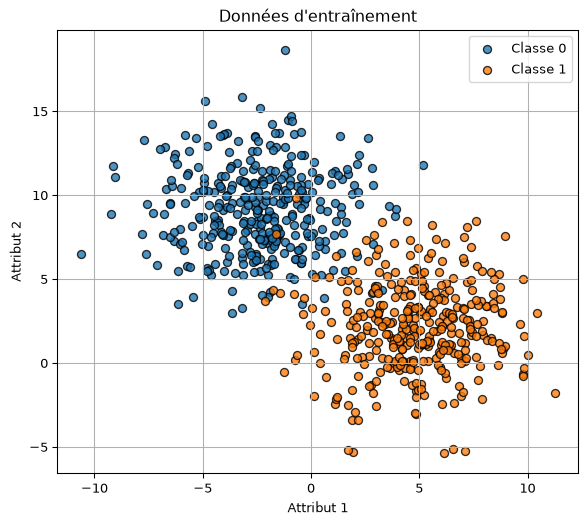

In [4]:
plt.figure(figsize=(7, 6))
plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    color="tab:blue",
    edgecolor="black",
    alpha=0.8,
    label="Classe 0",
)
plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    color="tab:orange",
    edgecolor="black",
    alpha=0.8,
    label="Classe 1",
)
plt.xlabel("Attribut 1")
plt.ylabel("Attribut 2")
plt.title("Données d'entraînement")
plt.legend()
plt.grid(True)
plt.show()

# Entraînement

In [5]:
model = LogisticRegression(learning_rate=0.1, max_iter=500)
model.fit(X_train, y_train)

print("Ordonnée à l'origine :", model.intercept_)
print("Coefficients des attributs :", model.coef_)

Ordonnée à l'origine : 1.0100587136980153
Coefficients des attributs : [ 1.06044862 -0.48332183]

La perte diminue à mesure que la descente de gradient par lot met à jour
le vecteur de paramètres.

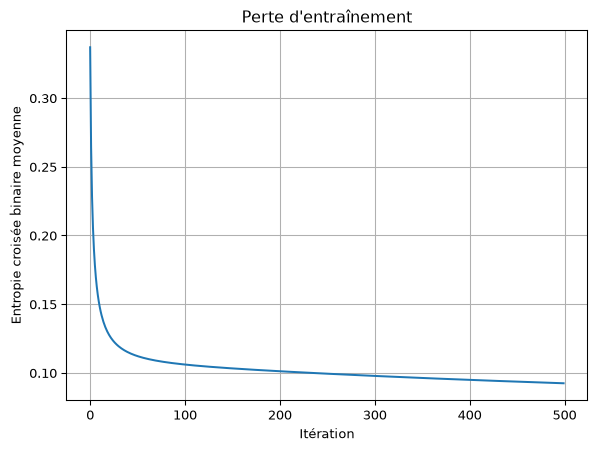

In [6]:
plt.figure(figsize=(7, 5))
plt.plot(model.get_loss_history())
plt.xlabel("Itération")
plt.ylabel("Entropie croisée binaire moyenne")
plt.title("Perte d'entraînement")
plt.grid(True)
plt.show()

# Surface de probabilité et frontière de décision

Le contour vert indique où $P(y=1\mid x)=0.5$. Soit
$w=(\theta_1,\theta_2)^\top$ le vecteur ajusté des poids des attributs.
Ce vecteur est normal à la frontière.

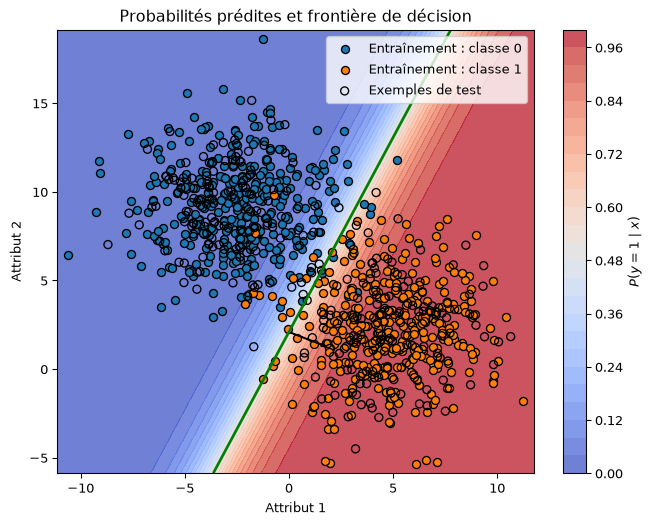

In [7]:
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
x1_grid, x2_grid = np.meshgrid(
    np.linspace(x1_min, x1_max, 250),
    np.linspace(x2_min, x2_max, 250),
)
grid = np.column_stack([x1_grid.ravel(), x2_grid.ravel()])
probability_grid = model.predict_proba(grid).reshape(x1_grid.shape)

plt.figure(figsize=(8, 6))
surface = plt.contourf(
    x1_grid,
    x2_grid,
    probability_grid,
    levels=25,
    cmap="coolwarm",
    alpha=0.75,
)
plt.colorbar(surface, label=r"$P(y=1\mid x)$")
plt.contour(
    x1_grid,
    x2_grid,
    probability_grid,
    levels=[0.5],
    colors="green",
    linewidths=2,
)

plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    color="tab:blue",
    edgecolor="black",
    label="Entraînement : classe 0",
)
plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    color="tab:orange",
    edgecolor="black",
    label="Entraînement : classe 1",
)
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    facecolors="none",
    edgecolors="black",
    marker="o",
    label="Exemples de test",
)

# Tracer le vecteur normal unitaire depuis un point de la frontière où x1 = 0.
normal = model.coef_
normal_unit = normal / np.linalg.norm(normal)
boundary_point = np.array([0.0, -model.intercept_ / normal[1]])
plt.arrow(
    boundary_point[0],
    boundary_point[1],
    normal_unit[0] * 2,
    normal_unit[1] * 2,
    width=0.03,
    head_width=0.18,
    color="black",
    length_includes_head=True,
)

plt.xlabel("Attribut 1")
plt.ylabel("Attribut 2")
plt.title("Probabilités prédites et frontière de décision")
plt.legend(loc="best")
plt.show()

La sigmoïde agit sur le score linéaire $\theta_0+w^\top x$. La distance
signée à la frontière divise ce score par $\lVert w\rVert$; les deux
quantités diffèrent donc lorsque le vecteur de poids n’est pas unitaire.